# Polynomial regression

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import skew
import pandas as pd

import os
from pathlib import Path

dataset_dir = os.path.join(Path.cwd(), '..', 'datasets')

In [2]:
data = pd.read_csv(f"{dataset_dir}/Turbine_Data.csv")
data.tail()

,Unnamed: 0,ActivePower,AmbientTemperatue,BearingShaftTemperature,Blade1PitchAngle,Blade2PitchAngle,Blade3PitchAngle,ControlBoxTemperature,GearboxBearingTemperature,GearboxOilTemperature,...,GeneratorWinding2Temperature,HubTemperature,MainBoxTemperature,NacellePosition,ReactivePower,RotorRPM,TurbineStatus,WTG,WindDirection,WindSpeed
118219,2020-03-30 23:10:00+00:00,70.044465,27.523741,45.711129,1.515669,1.950088,1.950088,0.0,59.821165,55.193793,...,58.148777,39.008931,36.476562,178.0,13.775785,9.234004,2.0,G01,178.0,3.533445
118220,2020-03-30 23:20:00+00:00,40.833474,27.602882,45.598573,1.702809,2.136732,2.136732,0.0,59.142038,54.798545,...,57.550367,39.006759,36.328125,178.0,8.088928,9.229370,2.0,G01,178.0,3.261231
118221,2020-03-30 23:30:00+00:00,20.777790,27.560925,45.462045,1.706214,2.139664,2.139664,0.0,58.439439,54.380456,...,57.099335,39.003815,36.131944,178.0,4.355978,9.236802,2.0,G01,178.0,3.331839
118222,2020-03-30 23:40:00+00:00,62.091039,27.810472,45.343827,1.575352,2.009781,2.009781,0.0,58.205413,54.079014,...,56.847239,39.003815,36.007805,190.0,12.018077,9.237374,2.0,G01,190.0,3.284468
118223,2020-03-30 23:50:00+00:00,68.664425,27.915828,45.231610,1.499323,1.933124,1.933124,0.0,58.581716,54.080505,...,56.741040,39.003815,35.914062,203.0,14.439669,9.235532,2.0,G01,203.0,3.475205


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 118224 entries, 0 to 118223
Data columns (total 22 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Unnamed: 0                    118223 non-null  str    
 1   ActivePower                   94750 non-null   float64
 2   AmbientTemperatue             93817 non-null   float64
 3   BearingShaftTemperature       62518 non-null   float64
 4   Blade1PitchAngle              41996 non-null   float64
 5   Blade2PitchAngle              41891 non-null   float64
 6   Blade3PitchAngle              41891 non-null   float64
 7   ControlBoxTemperature         62160 non-null   float64
 8   GearboxBearingTemperature     62540 non-null   float64
 9   GearboxOilTemperature         62438 non-null   float64
 10  GeneratorRPM                  62295 non-null   float64
 11  GeneratorWinding1Temperature  62427 non-null   float64
 12  GeneratorWinding2Temperature  62449 non-null   float64


In [16]:
print(data.isnull().sum())

data = data[['WindSpeed','RotorRPM','GeneratorRPM','ActivePower']]
data= data.dropna()

Unnamed: 0                          1
ActivePower                     23474
AmbientTemperatue               24407
BearingShaftTemperature         55706
Blade1PitchAngle                76228
Blade2PitchAngle                76333
Blade3PitchAngle                76333
ControlBoxTemperature           56064
GearboxBearingTemperature       55684
GearboxOilTemperature           55786
GeneratorRPM                    55929
GeneratorWinding1Temperature    55797
GeneratorWinding2Temperature    55775
HubTemperature                  55818
MainBoxTemperature              55717
NacellePosition                 45946
ReactivePower                   23476
RotorRPM                        56097
TurbineStatus                   55316
WTG                                 0
WindDirection                   45946
WindSpeed                       23629
dtype: int64


In [17]:
print(data.describe())
print(data.duplicated().sum())

          WindSpeed      RotorRPM  GeneratorRPM   ActivePower
count  61504.000000  61504.000000  61504.000000  61504.000000
mean       5.936167      9.894130   1103.308048    630.878634
std        2.564555      4.704424    524.264700    608.195747
min        0.900000      0.000000      0.000000    -38.524659
25%        3.921478      9.231065   1029.822747     90.396006
50%        5.673716     10.086061   1124.738534    423.642847
75%        7.592435     13.549569   1511.069220   1101.650567
max       22.970893     16.273495   1809.941700   1779.032433
16


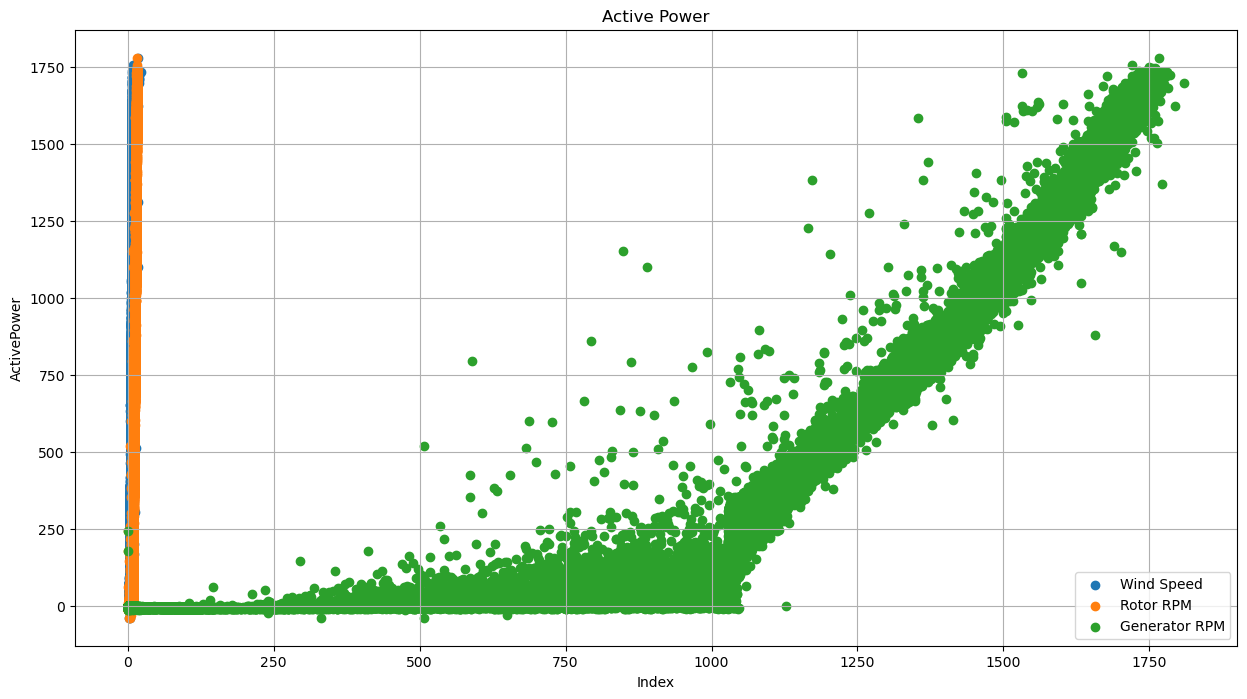

In [18]:
# Visualize the data

plt.figure(figsize=[15,8])
plt.scatter(x = data['WindSpeed'], y = data['ActivePower'], label = 'Wind Speed')
plt.scatter(x = data['RotorRPM'], y = data['ActivePower'], label = 'Rotor RPM')
plt.scatter(x = data['GeneratorRPM'], y = data['ActivePower'], label = 'Generator RPM')
plt.title('Active Power')
plt.xlabel('Index')
plt.ylabel('ActivePower')
plt.legend()
plt.grid(True)
plt.show()

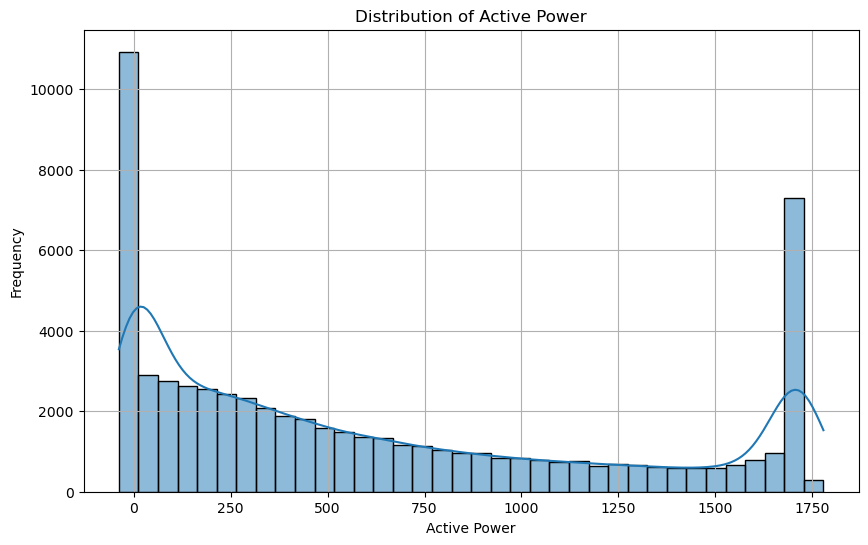

In [19]:
# distribution of the target variable
plt.figure(figsize=[10,6])
sns.histplot(data['ActivePower'], kde=True)
plt.title('Distribution of Active Power')
plt.xlabel('Active Power')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

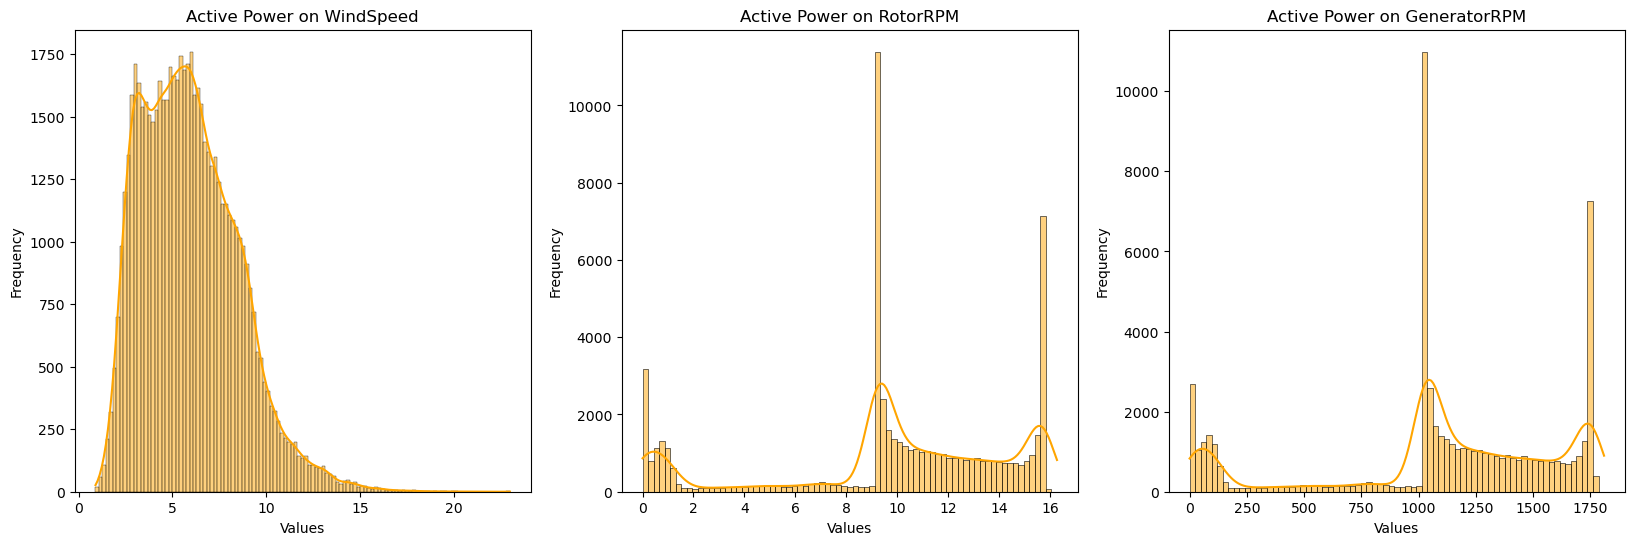

In [20]:
plt.figure(figsize=[20,6])
for i, column in enumerate(data[['WindSpeed','RotorRPM','GeneratorRPM']], 1):
    plt.subplot(1, 3, i)
    sns.histplot(data[column], color = 'orange', kde=True)
    plt.title(f'Active Power on {column}')
    plt.xlabel('Values')
    plt.ylabel('Frequency')

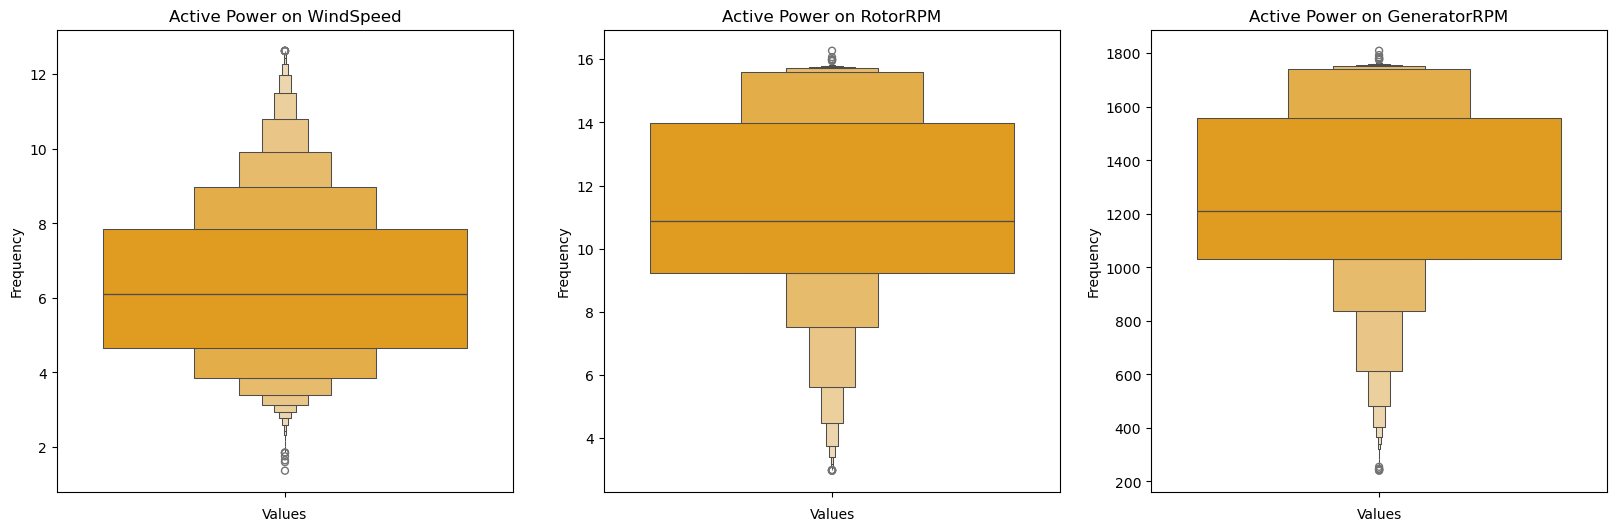

In [36]:
plt.figure(figsize=[20,6])
for i, column in enumerate(data[['WindSpeed','RotorRPM','GeneratorRPM']], 1):
    plt.subplot(1, 3, i)
    sns.boxenplot(data[column], color = 'orange')
    plt.title(f'Active Power on {column}')
    plt.xlabel('Values')
    plt.ylabel('Frequency')

In [22]:
# Remove outliers
filtered_dataset = data[['WindSpeed','RotorRPM','GeneratorRPM']]

print(f"Wind Speed Skewness:{filtered_dataset['WindSpeed'].skew()},\nRotor RPM Skewness: {filtered_dataset['RotorRPM'].skew()},\nGenerator RPM: {filtered_dataset['GeneratorRPM'].skew()}")

Wind Speed Skewness:0.7048757344568533,
Rotor RPM Skewness: -0.8032860235172069,
Generator RPM: -0.7955451433822047


- Wind speed is right skewed
- Rotor RPM is left skewed
- Generator RPM is left skewed

In [42]:
def remove_outliers(df: pd.DataFrame, column: str):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lb = Q1 - 1.5 * IQR
    ub = Q3 + 1.5 * IQR

    print(f"outliers: {df[(df[column] < lb) & (df[column] > ub)]}")
    return df[(df[column] >= lb) & (df[column] <= ub)]

In [43]:
data = remove_outliers(data, 'WindSpeed')
data = remove_outliers(data, 'RotorRPM')
data = remove_outliers(data, 'GeneratorRPM')

len(data)

outliers: Empty DataFrame
Columns: [WindSpeed, RotorRPM, GeneratorRPM, ActivePower]
Index: []
outliers: Empty DataFrame
Columns: [WindSpeed, RotorRPM, GeneratorRPM, ActivePower]
Index: []
outliers: Empty DataFrame
Columns: [WindSpeed, RotorRPM, GeneratorRPM, ActivePower]
Index: []


51544

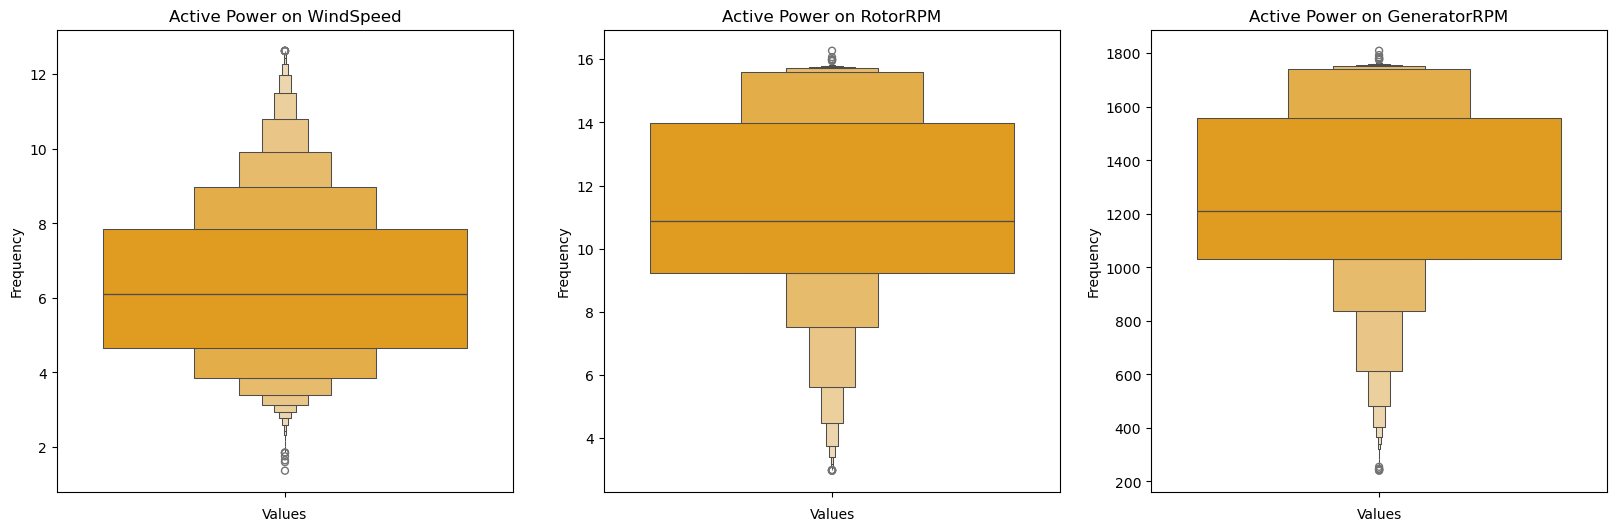

In [44]:
plt.figure(figsize=[20,6])
for i, column in enumerate(data[['WindSpeed','RotorRPM','GeneratorRPM']], 1):
    plt.subplot(1, 3, i)
    sns.boxenplot(data[column], color = 'orange')
    plt.title(f'Active Power on {column}')
    plt.xlabel('Values')
    plt.ylabel('Frequency')

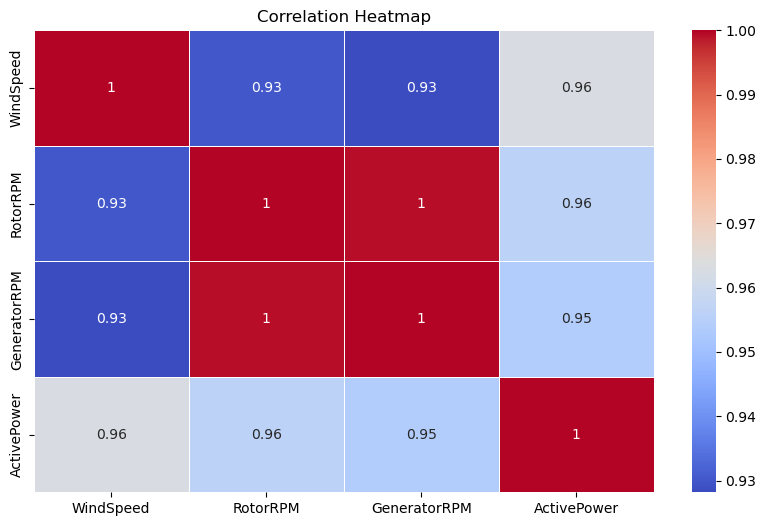

In [45]:
plt.figure(figsize=[10,6])

sns.heatmap(data[['WindSpeed','RotorRPM','GeneratorRPM','ActivePower']].corr(method='pearson'), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [46]:

X = data[['WindSpeed','RotorRPM','GeneratorRPM']]
y = data['ActivePower']

len(X), len(y)

(51544, 51544)

In [16]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
poly_transformer = PolynomialFeatures(degree=2)
X_poly = poly_transformer.fit_transform(X_train)

In [18]:
model = LinearRegression()
model.fit(X_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0. ,-0.27,-0. ,..., 0.01, 0.16,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,85.09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[2.18e+08,3.21e+05,3.17e+04,...,2.83e+01,9.43e+00,0.00e+00]"


In [20]:
y_train_pred = model.predict(X_poly)

poly_transformer = PolynomialFeatures(degree=2)
X_test_poly = poly_transformer.fit_transform(X_test)
y_test_pred = model.predict(X_test_poly)

In [19]:
# Coefficients of the model
print(f"Slope: {model.coef_}")
print(f"Intercept: {model.intercept_:.4f}")

Slope: [ 0.00000000e+00 -2.73057712e-01 -4.63863092e-03 -8.74375511e-01
 -5.86784981e+00 -2.91373728e-03  9.24367527e-02  7.28224826e-03
  1.60071255e-01 -7.35263049e-04]
Intercept: 85.0912


## Evaluate Model

In [21]:
# R-squared value
r2_train = r2_score(y_train, y_train_pred)
print(f"R-squared for {model.__class__.__name__} Train: {r2_train:.4f}")

r2_test = r2_score(y_test, y_test_pred)
print(f"R-squared for {model.__class__.__name__} Test: {r2_test:.4f}")

# Mean Squared Error
mse_train = mean_squared_error(y_train, y_train_pred)
print(f"Mean Squared Error for {model.__class__.__name__} Train: {mse_train:.4f}")

mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Mean Squared Error for {model.__class__.__name__} Test: {mse_test:.4f}")

R-squared for LinearRegression Train: 0.9895
R-squared for LinearRegression Test: 0.9887
Mean Squared Error for LinearRegression Train: 3900.7197
Mean Squared Error for LinearRegression Test: 4135.9435


Text(0, 0.5, 'Active Power')

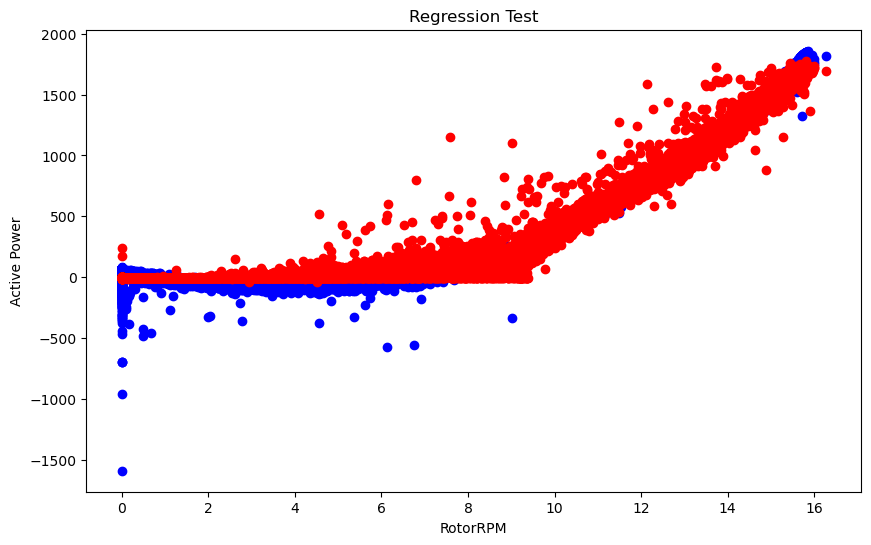

In [22]:
# Visualize the model's predictions
plt.figure(figsize=[10,6])
plt.scatter(X_train['RotorRPM'], y_train_pred, color='blue', label='Training Data')
plt.scatter(X_train['RotorRPM'], y_train, color='red', label='Regression Line')
plt.title('Regression Test')
plt.xlabel('RotorRPM')
plt.ylabel('Active Power')